Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.3094 - val_loss: 0.0201
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0190 - val_loss: 0.0069
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0108 - val_loss: 0.0051
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0075 - val_loss: 0.0056
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0071 - val_loss: 0.0055
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0073 - val_loss: 0.0051
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0081 - val_loss: 0.0055
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0072 - val_loss: 0.0067
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0076 - val_loss: 0.0058
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0076 - val_loss: 0.0058
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0072 - val_loss: 0.0051
Epoch 12/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.00

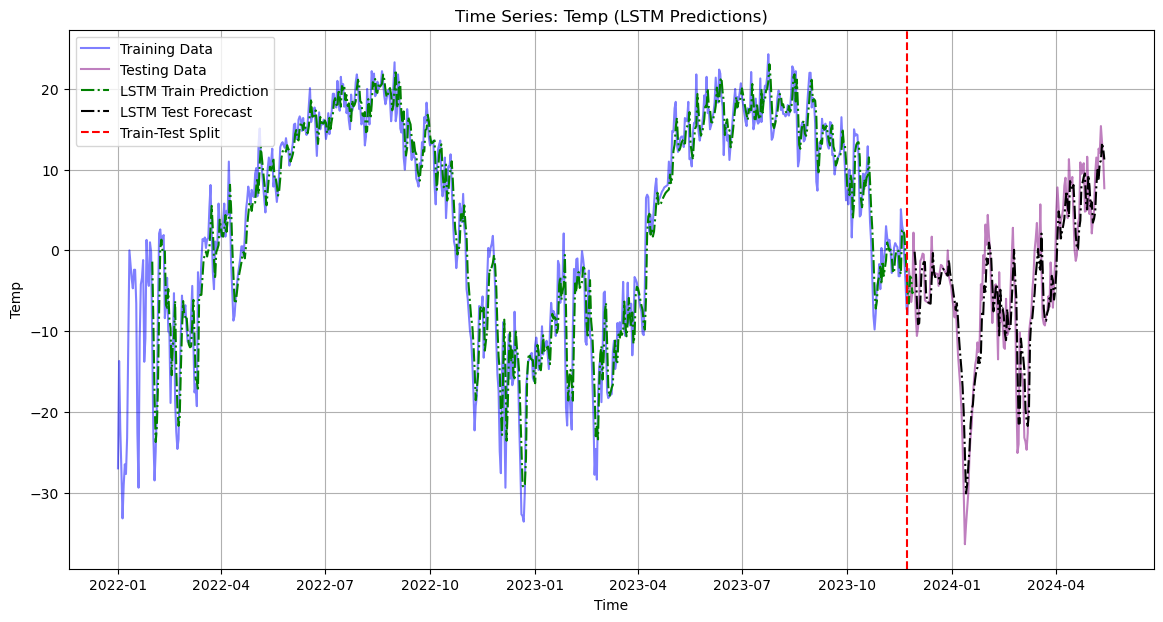

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# Load the data
data = pd.read_csv('temp_data.csv', parse_dates=['Time'], index_col='Time')

# Handle missing values: replace NaNs with 0
data['Temp'] = data['Temp'].fillna(0)

# Check for remaining NaNs (for debugging)
if data['Temp'].isna().any():
    print("Warning: NaN values still present in data after filling!")
    print(data[data['Temp'].isna()])
    raise ValueError("Data contains NaN values that could not be filled.")

# Train-test split (80% train, 20% test)
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

# --- LSTM Model ---
# Normalize the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[['Temp']])

# Create sequences
sequence_length = 30
X, y = [], []
for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])
X, y = np.array(X), np.array(y)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Train-test split for LSTM
train_size_lstm = int(len(X) * 0.8)
X_train, X_test = X[:train_size_lstm], X[train_size_lstm:]
y_train, y_test = y[:train_size_lstm], y[train_size_lstm:]

# Build LSTM model with Input layer
lstm_model = Sequential()
lstm_model.add(Input(shape=(sequence_length, 1)))  # Explicit input layer
lstm_model.add(LSTM(50, activation='relu'))        # No input_shape here
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

# Train LSTM
history = lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# In-sample prediction (training period)
lstm_train_pred = lstm_model.predict(X_train)
lstm_train_pred = scaler.inverse_transform(lstm_train_pred)
y_train_actual = scaler.inverse_transform([y_train])
lstm_train_rmse = np.sqrt(mean_squared_error(y_train_actual.T, lstm_train_pred))
lstm_train_r2 = r2_score(y_train_actual.T, lstm_train_pred)

# Forecast (test period)
lstm_test_pred = lstm_model.predict(X_test)
lstm_test_pred = scaler.inverse_transform(lstm_test_pred)
y_test_actual = scaler.inverse_transform([y_test])
lstm_test_rmse = np.sqrt(mean_squared_error(y_test_actual.T, lstm_test_pred))
lstm_test_r2 = r2_score(y_test_actual.T, lstm_test_pred)

# Print LSTM metrics
print(f"LSTM Training RMSE: {lstm_train_rmse:.4f}")
print(f"LSTM Training R-squared: {lstm_train_r2:.4f}")
print(f"LSTM Testing RMSE: {lstm_test_rmse:.4f}")
print(f"LSTM Testing R-squared: {lstm_test_r2:.4f}")

# --- Merged Plotting (Training, Testing, and LSTM Predictions) ---
plt.figure(figsize=(14, 7))

# Plot training data
plt.plot(train.index, train['Temp'], label='Training Data', color='blue', alpha=0.5)

# Plot testing data
plt.plot(test.index, test['Temp'], label='Testing Data', color='purple', alpha=0.5)

# Plot LSTM predictions (adjust indices to match sequence length)
lstm_train_index = data.index[sequence_length:sequence_length + len(lstm_train_pred)]
lstm_test_index = data.index[sequence_length + len(lstm_train_pred):sequence_length + len(lstm_train_pred) + len(lstm_test_pred)]
plt.plot(lstm_train_index, lstm_train_pred, label='LSTM Train Prediction', color='green', linestyle='-.')
plt.plot(lstm_test_index, lstm_test_pred, label='LSTM Test Forecast', color='black', linestyle='-.')

# Add vertical line to separate training and testing periods
plt.axvline(x=train.index[-1], color='red', linestyle='--', label='Train-Test Split')

# Customize plot
plt.title('Time Series: Temp (LSTM Predictions)')
plt.xlabel('Time')
plt.ylabel('Temp')
plt.legend()
plt.grid(True)
plt.show()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=4691.571, Time=0.87 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=4742.728, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=4740.213, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=4738.587, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=4740.827, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=4690.090, Time=0.41 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=4726.061, Time=0.17 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=4737.086, Time=0.30 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=4691.394, Time=0.61 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=4706.295, Time=0.28 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=4689.993, Time=0.38 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=4723.711, Time=0.20 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=4691.501, Time=0.71 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=4716.232, Time=0.24 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept

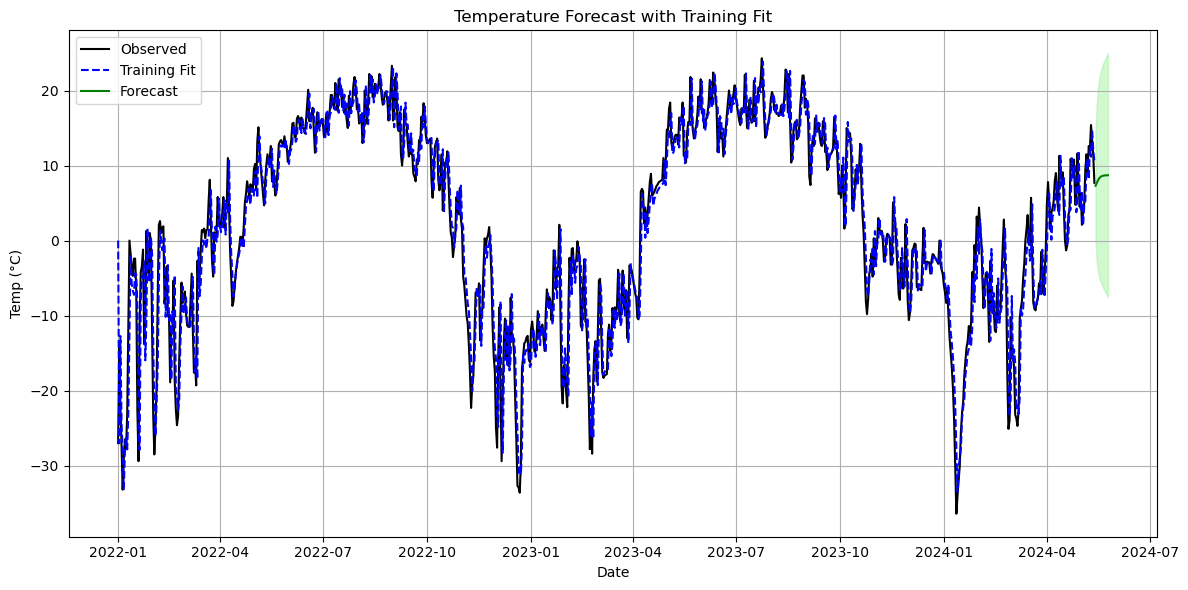

In [1]:
import pandas as pd
from pmdarima import auto_arima
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('temp_data.csv', index_col='Time', parse_dates=True)
y = data['Temp']

# Fit the auto_arima model
model = auto_arima(y,
    seasonal=False,      # Set to True if there's seasonality (e.g., weekly, yearly)
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

# Print model summary
print(model.summary())

# Get in-sample predictions (training fit)
fitted_values = model.predict_in_sample()

# Forecast the next 12 days
n_periods = 12
forecast, conf_int = model.predict(n_periods=n_periods, return_conf_int=True)

# Create future date index
future_dates = pd.date_range(start=y.index[-1] + pd.Timedelta(days=1), periods=n_periods)

# Plot observed, training fit, and forecast
plt.figure(figsize=(12, 6))
plt.plot(y.index, y, label='Observed', color='black')
plt.plot(y.index, fitted_values, label='Training Fit', color='blue', linestyle='--')
plt.plot(future_dates, forecast, label='Forecast', color='green')
plt.fill_between(future_dates, conf_int[:, 0], conf_int[:, 1], color='lightgreen', alpha=0.4)

plt.title('Temperature Forecast with Training Fit')
plt.xlabel('Date')
plt.ylabel('Temp (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
